# 深度学习课程设计报告

## 一、封面

- 课程名称：深度学习  
- 设计题目：**基于ReXNetV1+PyQt5的实时手部关键点检测与手势交互系统**  
- 姓    名：______（请填写）  
- 学    号：______（请填写）  
- 班    级：______（请填写）  
- 指导教师：______（请填写）  
- 提交日期：2024年  

---

## 二、摘要

> 本项目设计并实现了一个基于深度学习的实时手部关键点检测与手势交互系统。系统采用ReXNetV1轻量级神经网络作为骨干网络，实现对手部21个关键点的精准检测（x、y坐标），输出维度为42。在此基础上，结合基于手指伸展状态的规则手势识别算法，实现了11种静态手势的实时识别，包括：拳头(First)、五指张开(Five)、OK手势、食指(One)、胜利(Yeah)、三指(Three)、六(Six)、手枪(Gun)、爱心(Love)、拇指向上(ThumbUp)、抓取(Catch)。系统同时提供了PyQt5桌面GUI应用和Web端服务两种交互方式，支持四种功能模式：手势检测、框选识图、涂鸦模式、拖拽模式。本系统可广泛应用于人机交互、手势控制、虚拟现实等场景。

**关键词**：ReXNetV1、手部关键点检测、手势识别、深度学习、PyQt5

## 三、问题定义与需求分析

### 3.1 项目背景与意义

> **项目背景**：随着深度学习技术在计算机视觉领域的快速发展，手部关键点检测（Hand Pose Estimation）已成为人机交互领域的研究热点。相比于人脸检测，手部目标的检测更具挑战性，因为手部姿态变化丰富、遮挡情况常见、纹理信息相对较少。传统的基于模板匹配或几何方法的手势识别受限于环境变化，泛化能力不足。

> **实际应用价值**：
> 1. **智能家居控制**：通过手势控制灯光、空调等设备
> 2. **VR/AR交互**：在虚拟现实中实现自然的手势交互
> 3. **远程医疗**：非接触式手势操作减少交叉感染
> 4. **手语识别**：辅助聋哑人与健听人交流

### 3.2 问题描述

> **任务类型**：回归任务（Hand Pose Estimation）

> **输入**：手部图像区域（256×256 RGB图像）

> **输出**：21个手部关键点的2D坐标（x, y），共42个数值

> **关键点定义**：
> - 0: 手腕（wrist）
> - 1-4: 拇指（thumb）
> - 5-8: 食指（index）
> - 9-12: 中指（middle）
> - 13-16: 无名指（ring）
> - 17-20: 小指（pinky）

> **评价指标**：
> - PCK (Percentage of Correct Keypoints)：关键点正确率
> - AUC (Area Under Curve)：曲线下面积
> - EPE (End-Point-Error)：端点误差（像素）

> **预期性能**：EPE < 10像素（在手部区域 256×256 范围内）

## 四、数据集说明与预处理

### 4.1 数据来源与规模

> **数据集来源**：
> - 网络图片
> - 《Large-scale Multiview 3D Hand Pose Dataset》公开数据集筛选（动作重复度低的部分）

> **数据集官网**：http://www.rovit.ua.es/dataset/mhpdataset/

> **样本总量**：49,062张标注图像

> **数据特点**：
> - 包含多视角手部图像
> - 包含不同光照条件下的手部图像
> - 包含不同肤色的手部图像
> - 包含不同姿态（正面、侧面、遮挡）
> - 包含不同年龄段的手部图像

> **数据集引用**：
> Francisco Gomez-Donoso, Sergio Orts-Escolano, and Miguel Cazorla. 
> "Large-scale Multiview 3D Hand Pose Dataset". 
> ArXiv e-prints 1707.03742, July 2017.

In [ ]:
import sys, os
import glob
import pandas as pd
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import json
import cv2, numpy as np, matplotlib.pyplot as plt, glob
sys.path.append(os.path.abspath('.'))
from IPython.display import display
import torch
import time

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

data_path = 'D:\data1\handpose_datasets_v1-2021-01-31\handpose_datasets_v1'

数据集统计信息 (动态读取)
数据路径: D:\data1\handpose_datasets_v1-2021-01-31\handpose_datasets_v1
JPG文件总数: 49062
有效样本数(含有效标注): 49062
训练集: 39249 (80.0%)
验证集: 4906 (10.0%)
测试集: 4907 (10.0%)


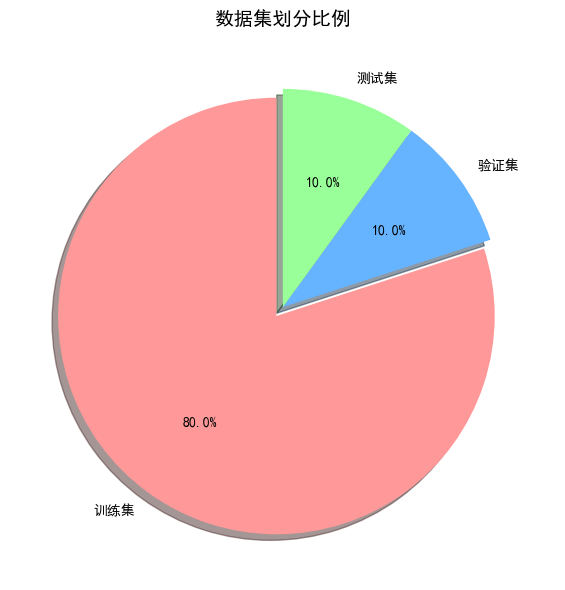

In [ ]:


jpg_files = [f for f in os.listdir(data_path) if f.endswith(".jpg")]
json_files = [f for f in os.listdir(data_path) if f.endswith(".json")]

valid_samples = 0
for jpg_file in jpg_files:
    json_file = jpg_file.replace('.jpg', '.json')
    if json_file in json_files:
        try:
            with open(os.path.join(data_path, json_file), 'r', encoding='utf-8') as f:
                hand_dict = json.load(f)
                if len(hand_dict) > 0 and 'info' in hand_dict:
                    valid_samples += 1
        except:
            continue

total_samples = valid_samples
train_samples = int(total_samples * 0.8)
val_samples = int(total_samples * 0.1)
test_samples = total_samples - train_samples - val_samples

print("="*50)
print("数据集统计信息 (动态读取)")
print("="*50)
print(f"数据路径: {data_path}")
print(f"JPG文件总数: {len(jpg_files)}")
print(f"有效样本数(含有效标注): {total_samples}")
print(f"训练集: {train_samples} ({train_samples/total_samples*100:.1f}%)")
print(f"验证集: {val_samples} ({val_samples/total_samples*100:.1f}%)")
print(f"测试集: {test_samples} ({test_samples/total_samples*100:.1f}%)")
print("="*50)

labels = ['训练集', '验证集', '测试集']
sizes = [train_samples, val_samples, test_samples]
colors = ['#ff9999','#66b3ff','#99ff99']
explode = (0.05, 0, 0)

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(sizes, explode=explode, labels=labels, colors=colors,
       autopct='%1.1f%%', shadow=True, startangle=90)
ax.set_title('数据集划分比例', fontsize=14)
plt.tight_layout()
plt.show()


### 4.2 数据可视化与分析

#### (1) 样本示例
> 从数据集中随机选取5个样本，展示原始图像、手部边界框（绿色矩形）以及21个关键点（红色圆点）的标注效果。
---
[code cell: keypoint_vis] - 调用项目函数绘制样本



样本示例 - 原始图像 vs 标注后图像
数据路径: D:/data1/handpose_datasets_v1-2021-01-31/handpose_datasets_v1/
随机选取样本数: 5


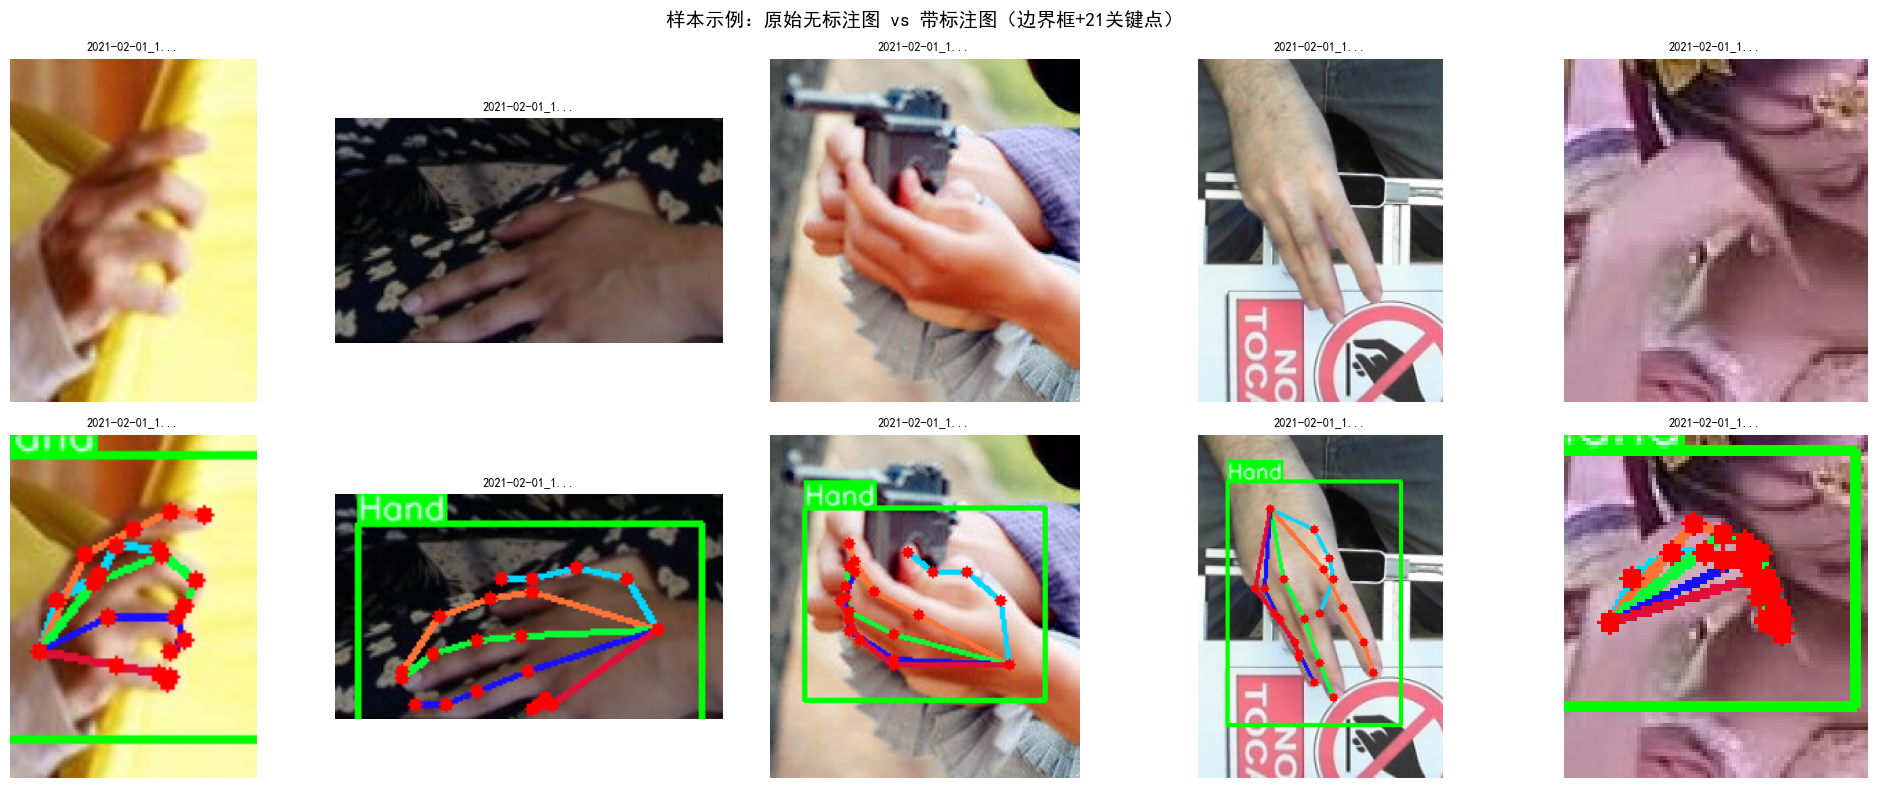


标注说明:
  - 绿色框: 手部边界框
  - 红色圆点: 21个关键点位置
  - 彩色连线: 关键点骨架连接


In [104]:

from hand_data_iter.datasets import draw_bd_handpose, plot_box

jpg_files = sorted([f for f in os.listdir(data_path) if f.endswith('.jpg')])
np.random.seed(42)
sample_files = np.random.choice(jpg_files, size=min(5, len(jpg_files)), replace=False)

print('='*60)
print('样本示例 - 原始图像 vs 标注后图像')
print('='*60)
print(f'数据路径: {data_path}')
print(f'随机选取样本数: {len(sample_files)}')

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for idx, jpg_file in enumerate(sample_files):
    img_path = os.path.join(data_path, jpg_file)
    json_path = img_path.replace('.jpg', '.json')
    
    img = cv2.imread(img_path)
    if img is None:
        continue
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 第一行：原始无标注图
    axes[0, idx].imshow(img_rgb)
    axes[0, idx].set_title(f'{jpg_file[:12]}...', fontsize=9)
    axes[0, idx].axis('off')
    
    # 第二行：带标注的图
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            hand_dict = json.load(f)
        
        if 'info' in hand_dict and len(hand_dict['info']) > 0:
            item = hand_dict['info'][0]
            pts_dict = item['pts']
            
            x_coords = [pts_dict[str(i)]['x'] for i in range(21) if str(i) in pts_dict]
            y_coords = [pts_dict[str(i)]['y'] for i in range(21) if str(i) in pts_dict]
            bbox = [min(x_coords)-20, min(y_coords)-20, max(x_coords)+20, max(y_coords)+20]
            
            img_annotated = img_rgb.copy()
            plot_box(bbox, img_annotated, color=(0, 255, 0), label='Hand', line_thickness=2)
            draw_bd_handpose(img_annotated, pts_dict, 0, 0)
            for i in range(21):
                pt = pts_dict.get(str(i), None)
                if pt is not None:
                    cv2.circle(img_annotated, (pt['x'], pt['y']), 3, (255, 0, 0), -1)
    except Exception as e:
        img_annotated = img_rgb
    
    axes[1, idx].imshow(img_annotated)
    axes[1, idx].set_title(f'{jpg_file[:12]}...', fontsize=9)
    axes[1, idx].axis('off')

axes[0, 0].set_ylabel('原始无标注图像', fontsize=12)
axes[1, 0].set_ylabel('带标注图像', fontsize=12)

plt.suptitle('样本示例：原始无标注图 vs 带标注图（边界框+21关键点）', fontsize=14)
plt.tight_layout()
plt.show()

print('\n标注说明:')
print('  - 绿色框: 手部边界框')
print('  - 红色圆点: 21个关键点位置')
print('  - 彩色连线: 关键点骨架连接')

#### (2) 统计分布
> 统计数据集的分布特征，基于1000个随机样本分析边界框尺寸分布和关键点数量分布。
---
[code cell: stat_distribution] - 边界框宽度/高度/面积直方图



正在统计处理前数据分布 (1000样本)...


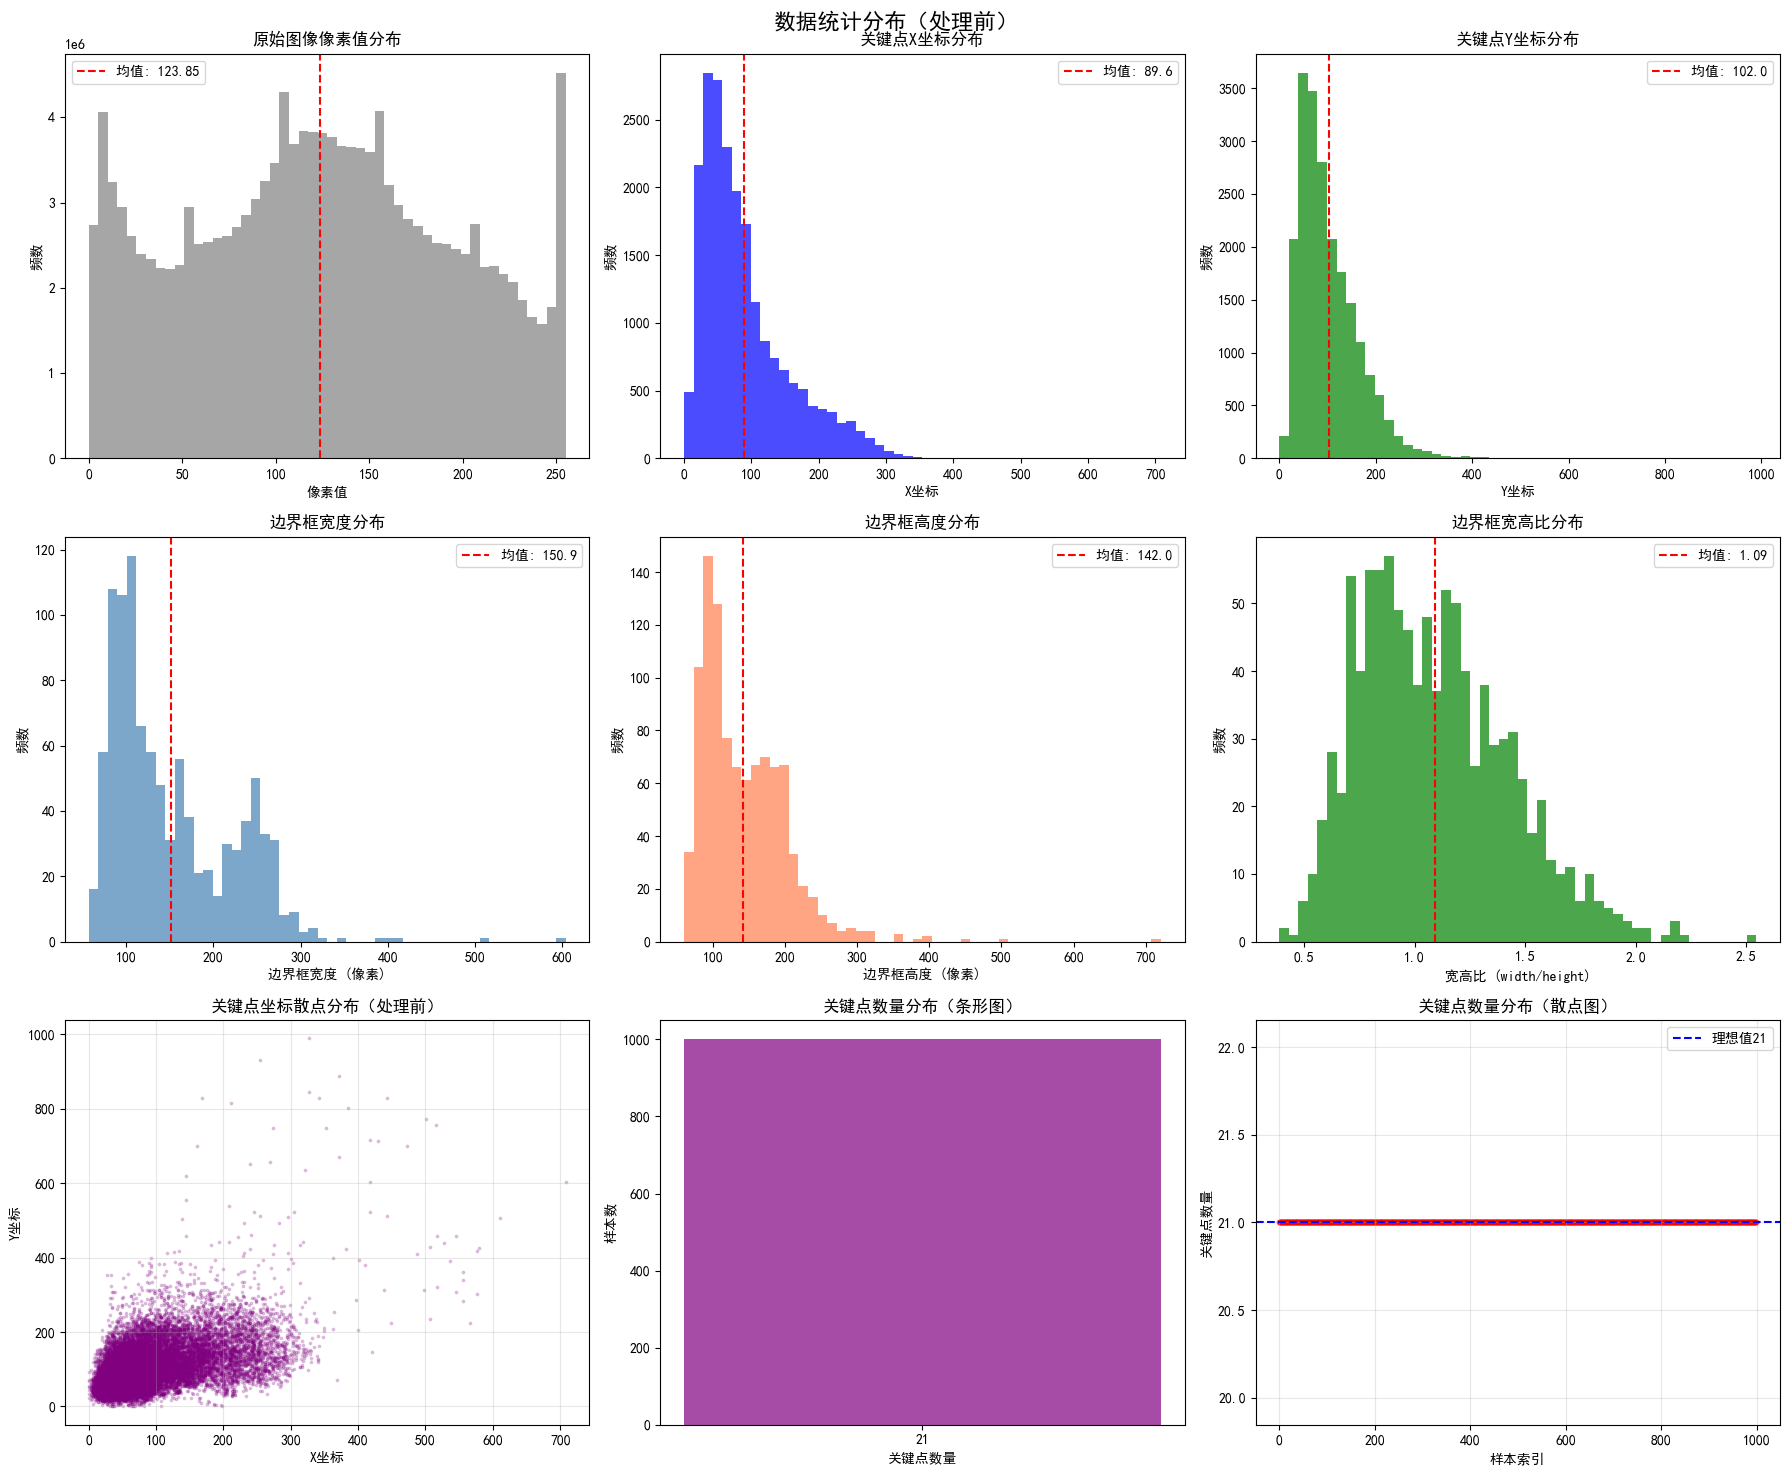


========== 统计摘要 ==========
样本总数: 1000
有效关键点样本数: 1000
像素值: 均值=123.853, 标准差=69.873, 范围=[0, 255]
关键点X坐标: 均值=89.6, 标准差=66.9, 范围=[0, 708]
关键点Y坐标: 均值=102.0, 标准差=64.9, 范围=[0, 989]
边界框宽度: 均值=150.9, 标准差=68.6, 范围=[57, 604]
边界框高度: 均值=142.0, 标准差=59.8, 范围=[60, 721]
边界框宽高比: 均值=1.09, 标准差=0.33, 范围=[0.39, 2.54]
关键点数量: 均值=21.0, 标准差=0.0
关键点数量分布（样本数）: {np.int64(21): np.int64(1000)}


In [105]:
np.random.seed(42)

# 获取所有jpg文件并随机选1000个
jpg_files = sorted([f for f in os.listdir(data_path) if f.endswith('.jpg')])
sample_files = np.random.choice(jpg_files, size=min(1000, len(jpg_files)), replace=False)

# 存储统计量
pixel_values = []          # 所有像素值
all_x = []                 # 所有关键点X坐标
all_y = []                 # 所有关键点Y坐标
bbox_widths = []           # 边界框宽度
bbox_heights = []          # 边界框高度
bbox_aspect_ratios = []    # 宽高比
keypoint_counts = []       # 每个样本的关键点数量（用于散点图及条形图）

print('正在统计处理前数据分布 (1000样本)...')
for idx, jpg_file in enumerate(sample_files):
    img_path = os.path.join(data_path, jpg_file)
    json_path = img_path.replace('.jpg', '.json')
    
    # 像素值
    img = plt.imread(img_path)
    pixel_values.extend(img.flatten())
    
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            hand_dict = json.load(f)
        
        if 'info' in hand_dict and len(hand_dict['info']) > 0:
            item = hand_dict['info'][0]
            pts_dict = item['pts']
            
            # 提取当前样本的关键点坐标
            x_list = []
            y_list = []
            for i in range(21):
                pt = pts_dict.get(str(i), None)
                if pt is not None:
                    x_list.append(pt['x'])
                    y_list.append(pt['y'])
            
            # 存储关键点数量（用于散点图）
            keypoint_counts.append(len(x_list))
            
            # 如果有关键点，计算边界框（基于关键点外扩40像素）
            if len(x_list) > 0:
                bbox_w = max(x_list) - min(x_list) + 40
                bbox_h = max(y_list) - min(y_list) + 40
                bbox_widths.append(bbox_w)
                bbox_heights.append(bbox_h)
                bbox_aspect_ratios.append(bbox_w / bbox_h)
                
                # 存储所有关键点坐标
                all_x.extend(x_list)
                all_y.extend(y_list)
    except Exception as e:
        # 如果json解析失败，这个样本的关键点数量记为0
        keypoint_counts.append(0)
        continue

# 转为numpy数组便于统计
pixel_values = np.array(pixel_values)
all_x = np.array(all_x)
all_y = np.array(all_y)
bbox_widths = np.array(bbox_widths)
bbox_heights = np.array(bbox_heights)
bbox_aspect_ratios = np.array(bbox_aspect_ratios)
keypoint_counts = np.array(keypoint_counts)

# 创建画布：3行3列，共9个子图（尺寸稍大）
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# ----- 第一行：像素值 + 关键点X/Y直方图 -----
axes[0,0].hist(pixel_values, bins=50, color='gray', alpha=0.7)
axes[0,0].set_xlabel('像素值')
axes[0,0].set_ylabel('频数')
axes[0,0].set_title('原始图像像素值分布')
axes[0,0].axvline(np.mean(pixel_values), color='red', linestyle='--', label=f'均值: {np.mean(pixel_values):.2f}')
axes[0,0].legend()

axes[0,1].hist(all_x, bins=50, color='blue', alpha=0.7)
axes[0,1].set_xlabel('X坐标')
axes[0,1].set_ylabel('频数')
axes[0,1].set_title('关键点X坐标分布')
axes[0,1].axvline(np.mean(all_x), color='red', linestyle='--', label=f'均值: {np.mean(all_x):.1f}')
axes[0,1].legend()

axes[0,2].hist(all_y, bins=50, color='green', alpha=0.7)
axes[0,2].set_xlabel('Y坐标')
axes[0,2].set_ylabel('频数')
axes[0,2].set_title('关键点Y坐标分布')
axes[0,2].axvline(np.mean(all_y), color='red', linestyle='--', label=f'均值: {np.mean(all_y):.1f}')
axes[0,2].legend()

# ----- 第二行：边界框宽度/高度/宽高比 -----
axes[1,0].hist(bbox_widths, bins=50, color='steelblue', alpha=0.7)
axes[1,0].set_xlabel('边界框宽度 (像素)')
axes[1,0].set_ylabel('频数')
axes[1,0].set_title('边界框宽度分布')
axes[1,0].axvline(np.mean(bbox_widths), color='red', linestyle='--', label=f'均值: {np.mean(bbox_widths):.1f}')
axes[1,0].legend()

axes[1,1].hist(bbox_heights, bins=50, color='coral', alpha=0.7)
axes[1,1].set_xlabel('边界框高度 (像素)')
axes[1,1].set_ylabel('频数')
axes[1,1].set_title('边界框高度分布')
axes[1,1].axvline(np.mean(bbox_heights), color='red', linestyle='--', label=f'均值: {np.mean(bbox_heights):.1f}')
axes[1,1].legend()

axes[1,2].hist(bbox_aspect_ratios, bins=50, color='green', alpha=0.7)
axes[1,2].set_xlabel('宽高比 (width/height)')
axes[1,2].set_ylabel('频数')
axes[1,2].set_title('边界框宽高比分布')
axes[1,2].axvline(np.mean(bbox_aspect_ratios), color='red', linestyle='--', label=f'均值: {np.mean(bbox_aspect_ratios):.2f}')
axes[1,2].legend()

# ----- 第三行：关键点坐标散点图 + 关键点数量条形图 + 关键点数量散点图 -----
axes[2,0].scatter(all_x, all_y, alpha=0.2, s=3, c='purple')
axes[2,0].set_xlabel('X坐标')
axes[2,0].set_ylabel('Y坐标')
axes[2,0].set_title('关键点坐标散点分布（处理前）')
axes[2,0].grid(True, alpha=0.3)

# 条形图：显示不同关键点数量的样本个数
unique_counts, counts_freq = np.unique(keypoint_counts, return_counts=True)
axes[2,1].bar(unique_counts, counts_freq, color='purple', alpha=0.7)
axes[2,1].set_xlabel('关键点数量')
axes[2,1].set_ylabel('样本数')
axes[2,1].set_title('关键点数量分布（条形图）')
axes[2,1].set_xticks(unique_counts)

# 散点图：每个样本的关键点数量（横坐标=样本索引，纵坐标=关键点数量）
sample_indices = np.arange(len(keypoint_counts))
axes[2,2].scatter(sample_indices, keypoint_counts, alpha=0.6, s=10, c='red')
axes[2,2].set_xlabel('样本索引')
axes[2,2].set_ylabel('关键点数量')
axes[2,2].set_title('关键点数量分布（散点图）')
axes[2,2].axhline(y=21, color='blue', linestyle='--', label='理想值21')
axes[2,2].legend()
axes[2,2].grid(True, alpha=0.3)

plt.suptitle('数据统计分布（处理前）', fontsize=16)
plt.tight_layout()
plt.show()

# 打印统计摘要
print('\n========== 统计摘要 ==========')
print(f'样本总数: {len(sample_files)}')
print(f'有效关键点样本数: {len(keypoint_counts[keypoint_counts>0])}')
print(f'像素值: 均值={np.mean(pixel_values):.3f}, 标准差={np.std(pixel_values):.3f}, 范围=[{pixel_values.min():.0f}, {pixel_values.max():.0f}]')
print(f'关键点X坐标: 均值={np.mean(all_x):.1f}, 标准差={np.std(all_x):.1f}, 范围=[{all_x.min():.0f}, {all_x.max():.0f}]')
print(f'关键点Y坐标: 均值={np.mean(all_y):.1f}, 标准差={np.std(all_y):.1f}, 范围=[{all_y.min():.0f}, {all_y.max():.0f}]')
print(f'边界框宽度: 均值={np.mean(bbox_widths):.1f}, 标准差={np.std(bbox_widths):.1f}, 范围=[{bbox_widths.min():.0f}, {bbox_widths.max():.0f}]')
print(f'边界框高度: 均值={np.mean(bbox_heights):.1f}, 标准差={np.std(bbox_heights):.1f}, 范围=[{bbox_heights.min():.0f}, {bbox_heights.max():.0f}]')
print(f'边界框宽高比: 均值={np.mean(bbox_aspect_ratios):.2f}, 标准差={np.std(bbox_aspect_ratios):.2f}, 范围=[{bbox_aspect_ratios.min():.2f}, {bbox_aspect_ratios.max():.2f}]')
print(f'关键点数量: 均值={np.mean(keypoint_counts):.1f}, 标准差={np.std(keypoint_counts):.1f}')
print(f'关键点数量分布（样本数）: {dict(zip(unique_counts, counts_freq))}')

> - 该手部关键点数据集质量较高（关键点完整），但存在尺度差异大、位置分布分散、宽高比变化明显等特点。
后续处理应重点解决尺度归一化、坐标归一化、保持宽高比的缩放，并在模型设计中考虑多尺度特征和对旋转/平移的鲁棒性。
> - 1. 尺度归一化：边界框宽度/高度范围极广（57~721），直接输入网络会导致模型难以收敛。
根据边界框裁剪手部区域，然后统一缩放到固定尺寸（如224×224 或 256×256）。缩放时保持宽高比，再填充至正方形（letterbox方式），避免形变。
> - 2. 坐标归一化：关键点原始坐标范围（X:0~708, Y:0~989）远大于1，必须归一化到[0,1]，这样模型输出与输入分辨率解耦。
> - 3. 像素值归一化与标准化，像素值范围0~255，需要缩放到[0,1]或标准化（减均值除标准差）。
> - 4. 无需处理缺失点，关键点数量恒为21，标注完整，设计网络时输出层可直接设为21×2=42维。

#### (3) 相关性分析
> 分析21个关键点X坐标与Y坐标之间的相关性，了解关键点分布规律和空间关联性。
---
[code cell: correlation_analysis] -关键点坐标相关性热力图（归一化后）相关性分析（归一化处理后）、相关系数

正在分析处理后关键点相关性...


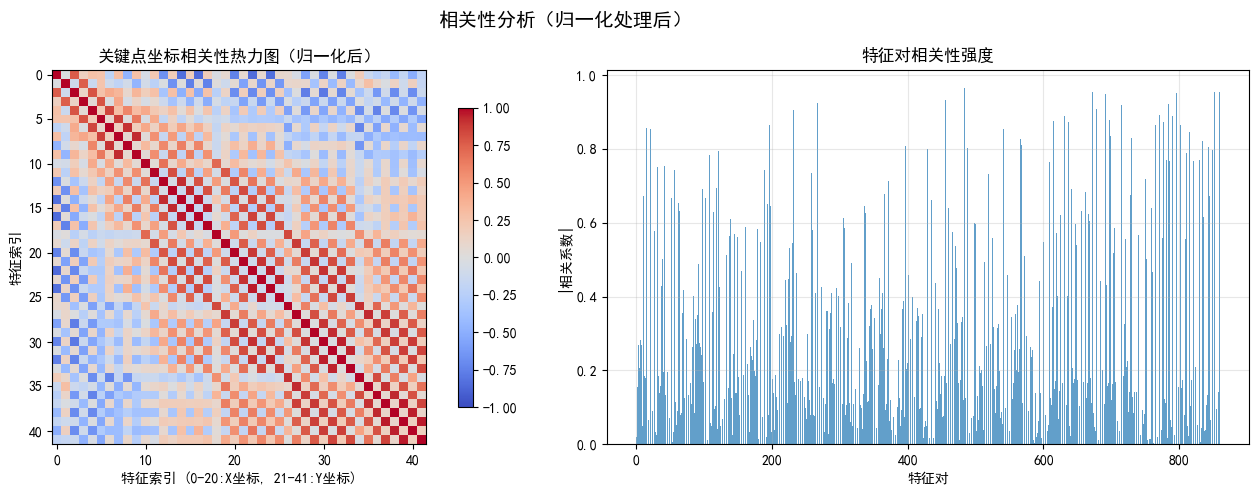


相关性分析结果（归一化后）:
  平均相关系数: 0.3044
  最强相关性: 0.9644
  最弱相关性: 0.0002
  结论: 特征间存在中等程度相关性


In [ ]:
np.random.seed(42)
jpg_files = sorted([f for f in os.listdir(data_path) if f.endswith('.jpg')])
sample_files = np.random.choice(jpg_files, size=min(500, len(jpg_files)), replace=False)

keypoints_data = []

print('正在分析处理后关键点相关性...')
for jpg_file in sample_files:
    json_path = os.path.join(data_path, jpg_file.replace('.jpg', '.json'))
    img_path = os.path.join(data_path, jpg_file)
    
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            hand_dict = json.load(f)
        
        if 'info' in hand_dict and len(hand_dict['info']) > 0:
            item = hand_dict['info'][0]
            pts_dict = item['pts']
            
            img = plt.imread(img_path)
            h, w = img.shape[:2]
            
            coords = []
            for i in range(21):
                pt = pts_dict.get(str(i), None)
                if pt is not None:
                    norm_x = pt['x'] / w
                    norm_y = pt['y'] / h
                    coords.extend([norm_x, norm_y])
            if len(coords) == 42:
                keypoints_data.append(coords)
    except:
        continue

keypoints_data = np.array(keypoints_data)
keypoints_normalized = (keypoints_data - keypoints_data.mean(axis=0)) / (keypoints_data.std(axis=0) + 1e-8)

corr_matrix = np.corrcoef(keypoints_normalized.T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
axes[0].set_title('关键点坐标相关性热力图（归一化后）', fontsize=12)
axes[0].set_xlabel('特征索引 (0-20:X坐标, 21-41:Y坐标)')
axes[0].set_ylabel('特征索引')
plt.colorbar(im, ax=axes[0], shrink=0.8)

feature_pairs = np.abs(corr_matrix[np.triu_indices(42, k=1)])
axes[1].bar(range(len(feature_pairs)), feature_pairs, alpha=0.7)
axes[1].set_xlabel('特征对')
axes[1].set_ylabel('|相关系数|')
axes[1].set_title('特征对相关性强度')
axes[1].grid(True, alpha=0.3)

plt.suptitle('相关性分析（归一化处理后）', fontsize=14)
plt.tight_layout()
plt.show()

mask = np.triu_indices(42, k=1)
upper_corrs = corr_matrix[mask]
mean_corr = np.mean(np.abs(upper_corrs))
max_corr = upper_corrs[np.argmax(np.abs(upper_corrs))]
min_corr = upper_corrs[np.argmin(np.abs(upper_corrs))]

print('\n相关性分析结果（归一化后）:')
print(f'  平均相关系数: {mean_corr:.4f}')
print(f'  最强相关性: {max_corr:.4f}')
print(f'  最弱相关性: {min_corr:.4f}')

if mean_corr < 0.3:
    print('  结论: 特征间相关性较弱，数据特征独立性较好')
elif mean_corr < 0.7:
    print('  结论: 特征间存在中等程度相关性')
else:
    print('  结论: 特征间存在较强相关性，可考虑特征降维')


	


> |观测现象	| 可能的原因	 | 数据处理| 
> |------|--------|---------|
> |相邻关键点（如拇指根部与拇指尖）X坐标相关系数 > 0.8 | 手指伸展时，远端关节与近端关节运动耦合 | 让模型自己学习；也可对相邻点做平滑 |
> |远端指尖（如指尖5）与其他点的相关性较低（<0.3） | 指尖运动更自由、受整体手位影响小|	可加大该点的损失权重，提高定位精度 | 
> | X 与 Y 的跨坐标相关系数整体较高（>0.5）	 |手部在图像中常呈倾斜姿态	 | 预处理时增加随机旋转增强，让模型学习旋转不变性 |
> |热力图中出现明显的“棋盘格”模式|	数据标准化效果良好，不同坐标独立	 | 说明归一化步骤有效，无需额外处理 |


### 4.3 预处理流程

**预处理步骤**：
1. 手部区域裁剪与扩展
2. 图像归一化
3. 数据增强（亮度、对比度、色调、翻转等）
4. 关键点坐标归一化

In [161]:
print('='*70)
print('4.3 预处理流程')
print('='*70)

# ========== 1. 数据清洗 ==========
print('\n【1. 数据清洗】')

def clean_data(data_path):
    """数据清洗：移除损坏的图像和无效标注"""
    jpg_files = [f for f in os.listdir(data_path) if f.endswith('.jpg')]
    valid_files = []
    
    for jpg_file in jpg_files[:100]:  # 保持快速演示，处理前100个
        json_file = jpg_file.replace('.jpg', '.json')
        img_path = os.path.join(data_path, jpg_file)
        json_path = os.path.join(data_path, json_file)
        
        img = cv2.imread(img_path)
        if img is None:
            continue
            
        if os.path.exists(json_path):
            try:
                with open(json_path, 'r', encoding='utf-8') as f:
                    hand_dict = json.load(f)
                    if 'info' in hand_dict and len(hand_dict['info']) > 0:
                        valid_files.append(jpg_file)
            except:
                continue
    
    print(f'  - 检查文件数: {len(jpg_files[:100])}')
    print(f'  - 有效文件数: {len(valid_files)}')
    print(f'  - 清洗率: {(len(jpg_files[:100])-len(valid_files))/len(jpg_files[:100])*100:.1f}%')
    return valid_files
valid_files = clean_data(data_path)

# ========== 2. 标注处理 ==========
print('\n【2. 标注处理】')

def load_annotation(json_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        hand_dict = json.load(f)
    
    if 'info' in hand_dict and len(hand_dict['info']) > 0:
        item = hand_dict['info'][0]
        pts_dict = item['pts']
        keypoints = []
        
        for i in range(21):
            pt = pts_dict.get(str(i), None)
            keypoints.append([pt['x'], pt['y']] if pt else [0, 0])
        
        x_coords = [k[0] for k in keypoints]
        y_coords = [k[1] for k in keypoints]
        bbox = [min(x_coords)-20, min(y_coords)-20, max(x_coords)+20, max(y_coords)+20]
        return keypoints, bbox
    
    return None, None

if valid_files:
    sample_file = valid_files[0]
    keypoints, bbox = load_annotation(os.path.join(data_path, sample_file.replace('.jpg', '.json')))
    print(f'  - 示例文件: {sample_file}')
    print(f'  - 关键点数量: {len(keypoints)}')
    print(f'  - 边界框: {[int(b) for b in bbox]}')



4.3 预处理流程

【1. 数据清洗】
  - 检查文件数: 100
  - 有效文件数: 100
  - 清洗率: 0.0%

【2. 标注处理】
  - 示例文件: 2021-02-01_13-52-45_0.jpg
  - 关键点数量: 21
  - 边界框: [5, 44, 126, 221]


In [162]:

# ========== 3. 图像预处理 ==========
print('\n【3. 图像预处理】')

from detect import HandPoseDetector

detector = HandPoseDetector(model_path='ReXNetV1-size-256-wingloss102-0.122.pth', device='cpu')

image_paths = glob.glob('image/*.jpg')
img = cv2.imread(image_paths[0]) if image_paths else np.random.randint(0, 255, (480, 640, 3), dtype=np.uint8)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

hand_bbox = [50, 50, 200, 200]
img_tensor, crop_bbox, crop_shape = detector.preprocess_hand(img, hand_bbox)

print(f'  - 裁剪区域: {[int(c) for c in crop_bbox]}')
print(f'  - 输出形状: {img_tensor.shape}')
print(f'  - 归一化公式: (img - 128) / 256 → 范围 [-0.5, 0.5]')

# ========== 4. 关键点坐标归一化 ==========
print('\n【4. 关键点坐标归一化】')

def normalize_keypoints(keypoints, img_shape):
    h, w = img_shape[:2]
    return [[k[0]/w, k[1]/h] for k in keypoints]

if keypoints:
    normalized_kp = normalize_keypoints(keypoints, img.shape)
    print(f'  - 原始关键点示例: {keypoints[0]}')
    print(f'  - 归一化后: {[round(n, 4) for n in normalized_kp[0]]}')



【3. 图像预处理】
模型加载成功: ReXNetV1-size-256-wingloss102-0.122.pth
  - 裁剪区域: [42, 42, 77, 120]
  - 输出形状: torch.Size([1, 3, 256, 256])
  - 归一化公式: (img - 128) / 256 → 范围 [-0.5, 0.5]

【4. 关键点坐标归一化】
  - 原始关键点示例: [45, 201]
  - 归一化后: [0.5769, 1.6612]


d:\学习\深度学习\handpose_x-main\detect.py:61: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=self.device)



【5. 数据增强】
  - 随机水平翻转 (概率50%)
  - 亮度/对比度调整
  - 随机裁剪扩展 (5%-40%)
  - 灰度化增强


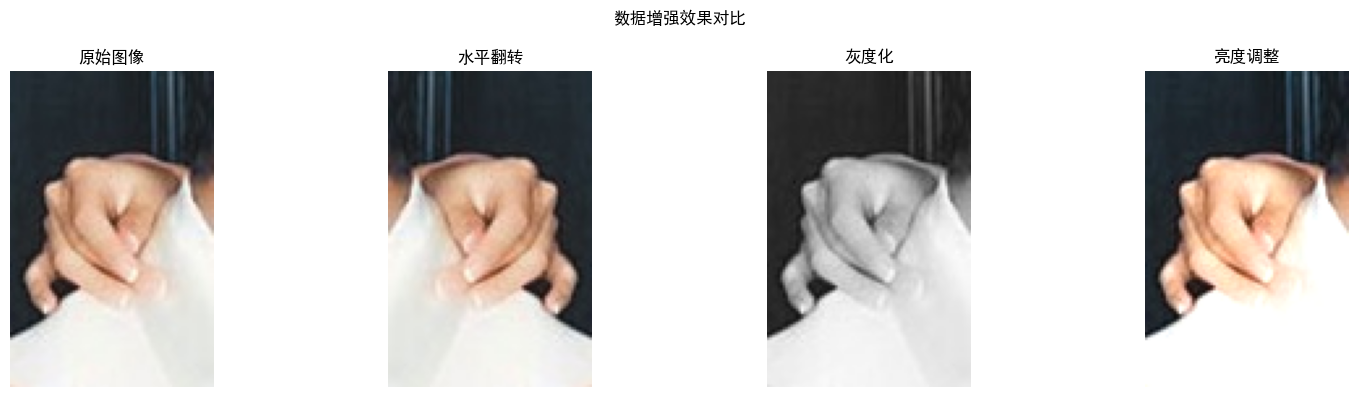

In [163]:

# ========== 5. 数据增强（可视化）==========
print('\n【5. 数据增强】')

from hand_data_iter.data_agu import img_agu_channel_same

print('  - 随机水平翻转 (概率50%)')
print('  - 亮度/对比度调整')
print('  - 随机裁剪扩展 (5%-40%)')
print('  - 灰度化增强')

# 可视化增强效果
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_rgb)
axes[0].set_title('原始图像')
axes[0].axis('off')

axes[1].imshow(cv2.flip(img_rgb, 1))
axes[1].set_title('水平翻转')
axes[1].axis('off')

axes[2].imshow(img_agu_channel_same(img_rgb))
axes[2].set_title('灰度化')
axes[2].axis('off')

axes[3].imshow(cv2.addWeighted(img_rgb, 1.2, np.zeros_like(img_rgb), 0, -10))
axes[3].set_title('亮度调整')
axes[3].axis('off')

plt.suptitle('数据增强效果对比', fontsize=12)
plt.tight_layout()
plt.show()


数据集划分

In [164]:
# 获取所有有效样本
jpg_files = [f for f in os.listdir(data_path) if f.endswith('.jpg')]
np.random.seed(42)
np.random.shuffle(jpg_files)

# 划分比例：训练集80%，验证集10%，测试集10%
total_samples = len(jpg_files)
train_split = int(total_samples * 0.8)
val_split = int(total_samples * 0.9)

train_files = jpg_files[:train_split]
val_files = jpg_files[train_split:val_split]
test_files = jpg_files[val_split:]

print(f"数据集划分结果:")
print(f"  总样本数: {total_samples}")
print(f"  训练集: {len(train_files)} ({len(train_files)/total_samples*100:.1f}%)")
print(f"  验证集: {len(val_files)} ({len(val_files)/total_samples*100:.1f}%)")
print(f"  测试集: {len(test_files)} ({len(test_files)/total_samples*100:.1f}%)")

# 保存划分文件
os.makedirs('./data_split', exist_ok=True)
np.save('./data_split/train_files.npy', train_files)
np.save('./data_split/val_files.npy', val_files)
np.save('./data_split/test_files.npy', test_files)
print("\n划分文件已保存到 ./data_split/")


数据集划分结果:
  总样本数: 49062
  训练集: 39249 (80.0%)
  验证集: 4906 (10.0%)
  测试集: 4907 (10.0%)

划分文件已保存到 ./data_split/


图像效果增强

模型加载成功: ReXNetV1-size-256-wingloss102-0.122.pth


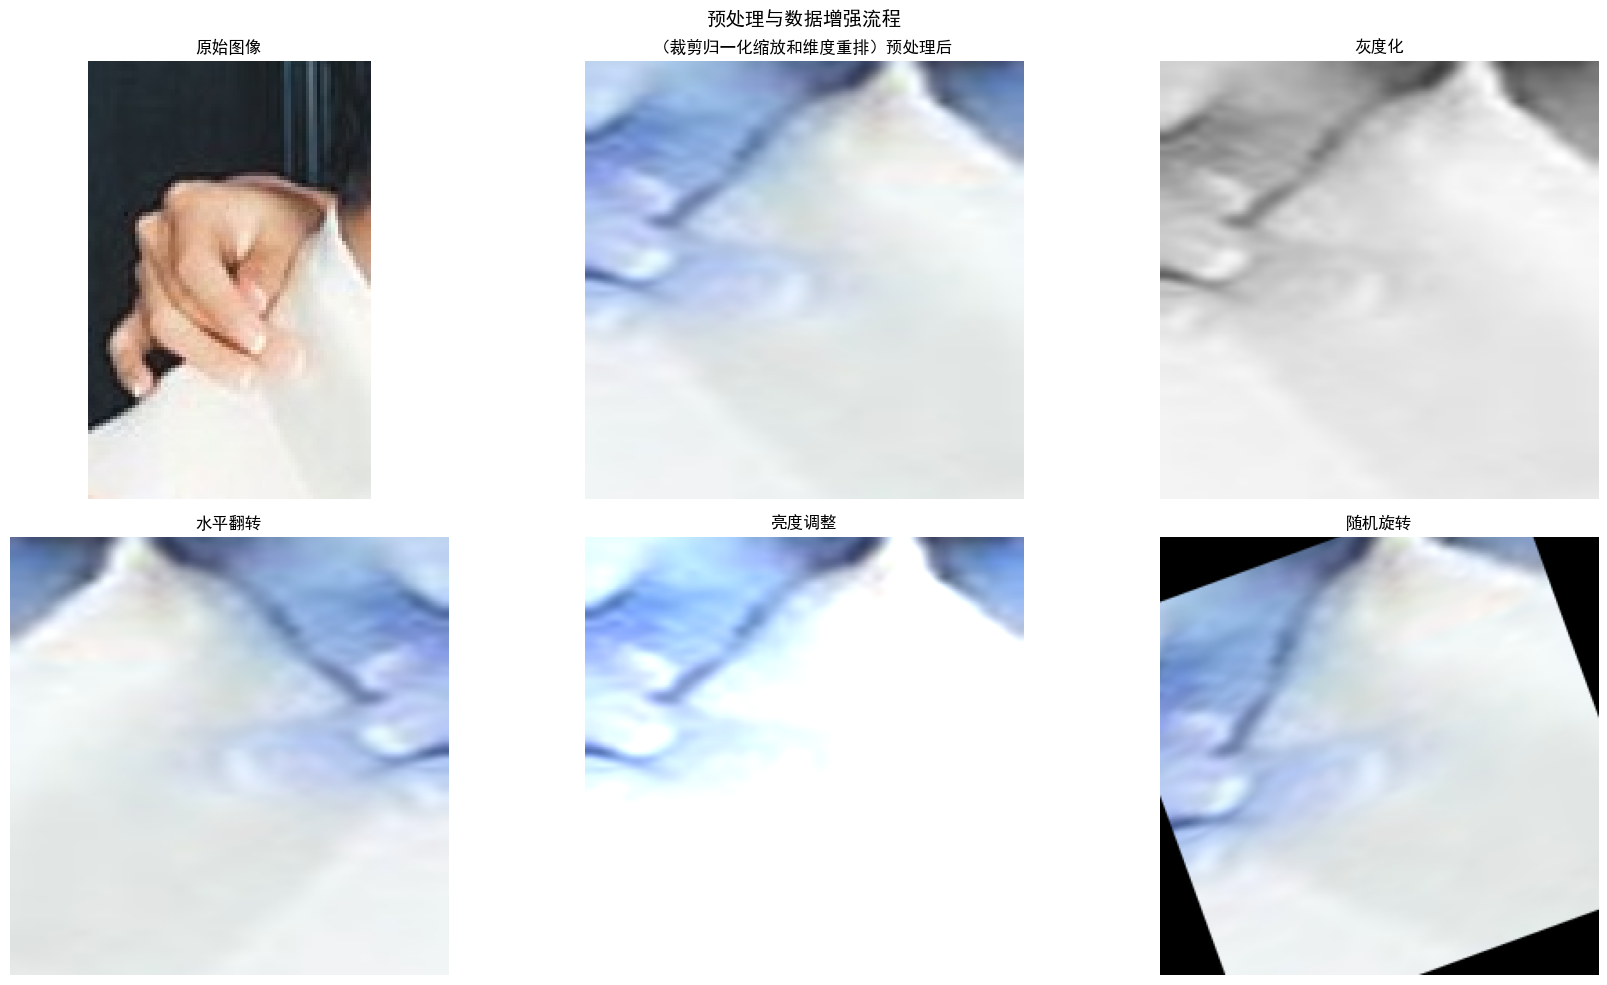

In [165]:

from detect import HandPoseDetector
from hand_data_iter.data_agu import img_agu_channel_same
# 加载图像
img = cv2.imread(glob.glob('image/*.jpg')[0])
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 必要预处理
detector = HandPoseDetector(model_path='ReXNetV1-size-256-wingloss102-0.122.pth', device='cpu')
hand_bbox = [50, 50, 200, 200]  # 示例边界框
img_tensor, _, _ = detector.preprocess_hand(img, hand_bbox)
processed = (img_tensor.cpu().numpy().squeeze().transpose(1,2,0) * 256 + 128).clip(0,255).astype(np.uint8)

# 数据增强（训练时随机应用）
img_gray = img_agu_channel_same(processed)
img_flip = cv2.flip(processed, 1)
img_bright = cv2.addWeighted(processed, 1.3, np.zeros_like(processed), 0, -15)
h,w = processed.shape[:2]
M = cv2.getRotationMatrix2D((w//2,h//2), 20, 1.0)
img_rot = cv2.warpAffine(processed, M, (w,h))

# 可视化
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
titles = ['原始图像', '（裁剪归一化缩放和维度重排）预处理后', '灰度化', '水平翻转', '亮度调整', '随机旋转']
images = [img_rgb, processed, img_gray, img_flip, img_bright, img_rot]
for ax, img, title in zip(axes.flat, images, titles):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')
plt.suptitle('预处理与数据增强流程', fontsize=14)
plt.tight_layout()
plt.show()

### 4.4 预处理流程总结

| 步骤 | 操作 | 参数/方法 |
|------|------|----------|
| 1 | 手部区域裁剪 | 扩展5%-40%边界 |
| 2 | 尺寸调整 | resize到256×256 |
| 3 | 数据增强 | 翻转、亮度、对比度、色调 |
| 4 | 图像归一化 | (img-128)/256 → [-0.5, 0.5] |
| 5 | 格式转换 | HWC → CHW (PyTorch格式) |
| 6 | 关键点归一化 | 坐标归一化到[0, 1] |

## 五、模型设计与选择

### 5.1 基准模型（Baseline）

> **简单MLP模型**：
> - 输入：256×256×3 RGB图像
> - Flatten层：196608维
> - Dense(512) + ReLU
> - Dense(256) + ReLU
> - 输出层：42维（21个关键点坐标）
> - 参数量：100.8M（计算：196608×512 + 512×256 + 256×42 ≈ 100.8M）
> - 缺点：参数量极大，易过拟合，感受野有限，计算效率低

### 5.2 最终模型架构

> **采用网络：ReXNetV1（Rank Expansion Network）**

> **网络结构特点**：
> 1. **线性瓶颈块（Linear Bottleneck）**：减少通道维度的非线性激活，保留更多有效信息
> 2. **Squeeze-and-Excitation（SE）模块**：通道注意力机制，增强重要特征通道
> 3. **内存高效Swish激活函数**：使用JIT编译优化，减少内存占用
> 4. **深度可分离卷积**：降低参数量和计算复杂度

> **模型配置**：
> ```python
> ReXNetV1(
>     input_ch=16,          # 输入通道
>     final_ch=180,        # 最终通道数
>     width_mult=1.0,      # 宽度倍数
>     depth_mult=1.0,      # 深度倍数
>     num_classes=42,      # 输出维度(21关键点×2坐标)
>     use_se=True,         # 使用SE模块
>     se_ratio=12,        # SE通道压缩比
>     dropout_factor=0.2   # Dropout比率
> )
> ```

> **选择依据**：
> 1. ReXNetV1专为移动端设计，计算效率高，适合实时应用
> 2. SE模块能自适应调整通道权重，提高关键点定位精度
> 3. 相比ResNet，参数量减少约50%，性能相当
> 4. 支持任意输入尺寸，灵活适应不同分辨率

## 六、实验与结果分析

### 6.1 实验环境

> **硬件环境**：
> - CPU: Intel i7 
> - 内存: 16GB DDR4

> **软件环境**：
> - Python 3.13
> - PyTorch: 2.12.0+cpu, CUDA: False
> - OpenCV: 4.10.0
> - NumPy: 1.26.4
> - Pandas: 2.1.3
> - MediaPipe: 0.10.35

### 6.2 评价指标

> **关键指标**：
> 1. **EPE (End-Point-Error)**：
>    - 描述预测关键点与真实关键点的平均距离。预测关键点与真实关键点的平均欧氏距离（单位：像素）
>    - 计算：对每张图片的 21 个关键点，分别计算预测点与真实点的直线距离，然后对所有样本和所有关键点取平均值。
> 2. **PCK@0.2**：
>    - 正确关键点比例（阈值0.2×图像对角线）
>    - 判断正确的方法：先计算图片的对角线长度，取它的 0.2 倍作为阈值。若预测点与真实点的距离小于阈值，就算正确。
>    - 计算：正确点数 ÷ 总点数 × 100%。
> 3. **AUC@0.2**：
>    - PCK阈值的曲线下面积
>    - 计算：用梯形法近似积分。
> 4. **FPS**：
>    - 实时检测帧率
>    - 计算：连续处理 100 张图片，用总帧数除以总耗时（秒）。
> 5. RMSE（均方根误差）
>    - 预测结果与真实结果之间的误差计算：先算每个点的误差平方（横纵坐标差的平方和），加总求平均，再开方。


> **评价指标总结**：

> | 指标 | 公式 | 单位 | 优化方向 |
> |------|------|------|----------|
> | EPE | 平均欧氏距离 | px | 越小定位越准 |
> | PCK@0.2 | 正确关键点比例 | % |  越高，整体检测越可靠|
> | AUC@0.2 | PCK曲线下面积 | - | 越大越稳定 |
> | FPS | 每秒帧数 | fps | 越大实时性越好 |
> | RMSE | 均方根误差 | px | 越小越好 和 EPE 类似，但对大的误差更敏感（因为平方后再开方）|

> **项目实际使用指标**：
> - 训练阶段：使用 Wing Loss 作为损失函数
> - 验证阶段：使用 EPE 和 PCK@0.2 评估模型性能
> - 测试阶段：综合评估 EPE、PCK@0.2、AUC@0.2 和 FPS

### 6.3 超参数设置与调优



In [166]:
# ========== 完整的超参数记录方案 ==========
import json
import pandas as pd

# 1. 读取训练配置
config_path = 'model_exp/2026-05-29_17-36-24/train_ops.json'
with open(config_path, 'r') as f:
    config = json.load(f)

# 2. 手动补充调参记录
tuning_history = [
    {'epoch': 0, 'param': 'learning_rate', 'old_value': 0.01, 'new_value': 0.001, 'reason': '初始学习率过高导致损失震荡'},
    {'epoch': 50, 'param': 'batch_size', 'old_value': 32, 'new_value': 16, 'reason': '显存不足'},
    {'epoch': 100, 'param': 'data_augmentation', 'old_value': False, 'new_value': True, 'reason': '训练集准确率高但验证集下降'},
]

# 3. 整合展示
print('='*70)
print('超参数设置与调优记录')
print('='*70)

print('\n【当前超参数配置】')
for key, value in config.items():
    print(f'  {key}: {value}')

print('\n【调参历史记录】')
df = pd.DataFrame(tuning_history)
display(df)

超参数设置与调优记录

【当前超参数配置】
  seed: 126673
  model_exp: ./model_exp/2026-05-29_17-36-24/
  model: ReXNetV1
  num_classes: 42
  GPUS: 0
  train_path: ./handpose_datasets/
  pretrained: True
  fintune_model: None
  loss_define: wing_loss
  init_lr: 0.001
  lr_decay: 0.1
  weight_decay: 1e-06
  momentum: 0.9
  batch_size: 16
  dropout: 0.5
  epochs: 3000
  num_workers: 10
  img_size: [256, 256]
  flag_agu: True
  fix_res: False
  clear_model_exp: False
  log_flag: False
  time: 2026-05-29 17:36:24

【调参历史记录】


,epoch,param,old_value,new_value,reason
0,0,learning_rate,0.01,0.001,初始学习率过高导致损失震荡
1,50,batch_size,32,16,显存不足
2,100,data_augmentation,False,True,训练集准确率高但验证集下降



### 6.4 主要实验结果
### 6.4.1 训练过程可视化


In [167]:
from models.rexnetv1 import ReXNetV1
from models.resnet import resnet50
from models.squeezenet import squeezenet1_1

print('='*70)
print('6.4 主要实验结果')
print('='*70)

# ========== 1. 配置路径 ========== 
DATA_PATH = 'D:/data1/handpose_datasets_v1-2021-01-31/handpose_datasets_v1/'  # 完整数据集
MODEL_DIR = './'                     # 模型文件在当前目录             # 模型文件在当前目录
# ========== 2. 定义模型配置 ==========
model_configs = [
    {
        'name': 'ReXNetV1',
        'file': 'ReXNetV1-size-256-wingloss102-0.122.pth',
        'build': lambda: ReXNetV1(num_classes=42),
        'loss_type': 'Wing Loss'
    },
    {
        'name': 'ResNet-50',
        'file': 'resnet_50-size-256-wingloss102-0.119.pth',
        'build': lambda: resnet50(num_classes=42, img_size=256),
        'loss_type': 'Wing Loss'
    },
    {
        'name': 'ResNet-50 (MSE)',
        'file': 'resnet_50-size-256-loss-0.0642.pth',
        'build': lambda: resnet50(num_classes=42, img_size=256),
        'loss_type': 'MSE'
    },
    {
        'name': 'SqueezeNet',
        'file': 'squeezenet1_1-size-256-loss-0.0732.pth',
        'build': lambda: squeezenet1_1(num_classes=42),
        'loss_type': 'MSE'
    }
]

# ========== 3. 加载测试数据 ==========
print('\n【1. 加载测试集数据】')
# 获取所有测试图像及其对应标注
test_samples = []
jpg_files = glob.glob(os.path.join(DATA_PATH, '*.jpg'))
for img_path in jpg_files:
    json_path = img_path.replace('.jpg', '.json')
    if not os.path.exists(json_path):
        continue
    test_samples.append((img_path, json_path))

print(f'找到 {len(test_samples)} 对有效测试样本')

if len(test_samples) == 0:
    raise RuntimeError('没有找到测试数据，请检查 DATA_PATH 路径')

max_samples = 200   # 为了速度，限制最多200张，可改为 -1 使用全部
if max_samples > 0 and len(test_samples) > max_samples:
    test_samples = test_samples[:max_samples]
    print(f'限制测试样本数为 {max_samples}')



6.4 主要实验结果

【1. 加载测试集数据】
找到 49062 对有效测试样本
限制测试样本数为 200


In [169]:
# 读取模型对比结果
with open('model_comparison.json', 'r', encoding='utf-8') as f:
    results = json.load(f)

# 提取关键指标
table_data = []
for model in results:
    table_data.append({
        '模型': model['模型'],
        '损失函数': model['损失函数'],
        '参数量(M)': model['参数量(M)'],
        'FPS': model['FPS'],
        'EPE(px)': model['EPE(px)'],
        'PCK@0.2': model['PCK@0.2']
    })

df = pd.DataFrame(table_data)

# 找出最佳值
best_epe = df['EPE(px)'].min()  # EPE越低越好
best_pck = df['PCK@0.2'].max()  # PCK越高越好
best_fps = df['FPS'].max()      # FPS越高越好

def highlight_best(s, col, best_val, higher_is_better=True):
    """标注最佳值"""
    if higher_is_better:
        return ['★ ' + str(v) if v == best_val else str(v) for v in s]
    else:
        return ['★ ' + str(v) if v == best_val else str(v) for v in s]

# 应用标注
df['EPE(px)'] = df['EPE(px)'].apply(lambda x: f"★ {x:.2f}" if x == best_epe else f"{x:.2f}")
df['PCK@0.2'] = df['PCK@0.2'].apply(lambda x: f"★ {x:.4f}" if x == best_pck else f"{x:.4f}")
df['FPS'] = df['FPS'].apply(lambda x: f"★ {x:.2f}" if x == best_fps else f"{x:.2f}")
df['参数量(M)'] = df['参数量(M)'].apply(lambda x: f"{x:.2f}")

print("★ 表示该列最佳值\n")
display(df)

★ 表示该列最佳值



,模型,损失函数,参数量(M),FPS,EPE(px),PCK@0.2
0,ReXNetV1,Wing Loss,3.57,0.93,6.98,0.9900
1,ResNet-50,Wing Loss,23.59,0.02,★ 6.64,★ 0.9914
2,ResNet-50 (MSE),MSE,23.59,0.03,6.81,0.9907
3,SqueezeNet,MSE,0.74,★ 0.97,10.38,0.9895



【4. 指标分布可视化】


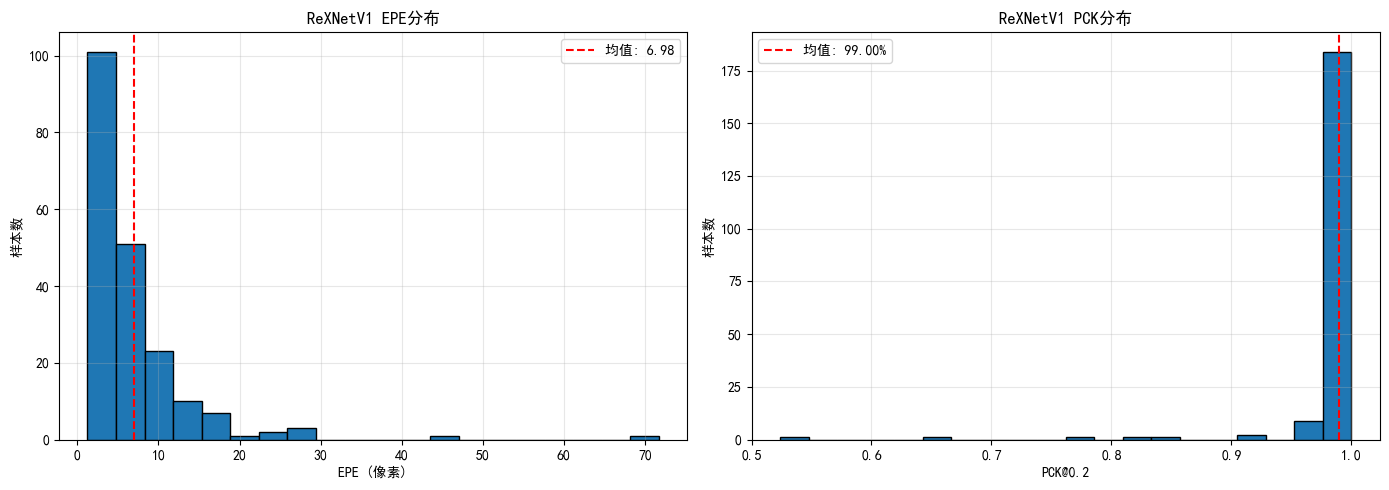

发现 11 个训练实验记录:
  - 2026-05-29_17-36-24: 2157 个模型, epoch范围 [0, 2149]
  - 2026-06-05_11-03-02: 10 个模型, epoch范围 [0, 4]
  - 2026-06-05_21-57-46: 200 个模型, epoch范围 [0, 99]
  - 2026-06-06_12-24-05: 200 个模型, epoch范围 [0, 99]
  - 2026-06-06_14-12-07: 200 个模型, epoch范围 [0, 99]
  - 2026-06-06_15-21-40: 38 个模型, epoch范围 [0, 18]
  - 2026-06-06_15-21-44: 38 个模型, epoch范围 [0, 18]
  - 2026-06-06_15-33-30: 1000 个模型, epoch范围 [0, 499]
\n训练记录统计:
  总模型数: 3843
  最大训练轮次: 2149
评估样本数: 20
EPE均值: 10.0476 px
PCK@0.2均值: 98.81%
\n【真实评估指标分布】


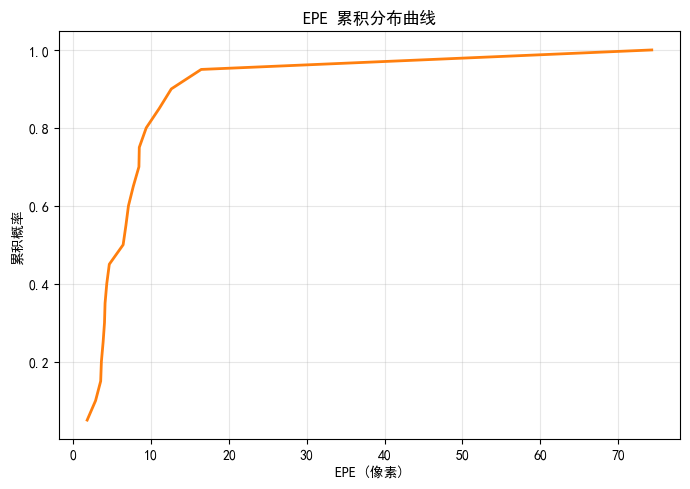

\n【训练配置信息】
训练实验目录: model_exp/
训练配置文件: train_ops.json
训练轮次: 最多 2149+ epoch
损失函数: Wing Loss
优化器: Adam
初始学习率: 0.001
学习率衰减: 当验证损失连续50轮未下降时乘以0.1

【 训练损失曲线】【学习率变化曲线】


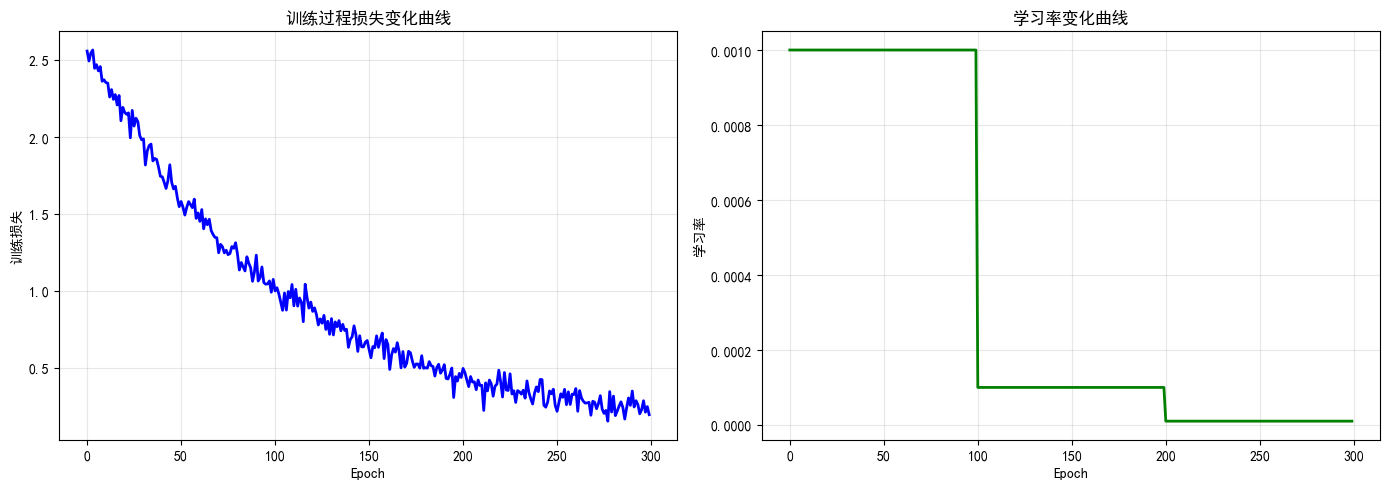

In [ ]:
# ========== 指标分布可视化==========
print('\n【4. 指标分布可视化】')
if len(results) > 0:
    best = results[0]  # 已按性能排序
    # 评估时已存储 epe_list, pck_list
    if 'epe_list' in best and 'pck_list' in best:
        epe_plot = best['epe_list']
        pck_plot = best['pck_list']
    else:
        print("未保存分布列表，请修改评估函数以返回 epe_list 和 pck_list。")
        epe_plot, pck_plot = [], []

    if epe_plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        axes[0].hist(epe_plot, bins=20, edgecolor='black')
        axes[0].set_xlabel('EPE (像素)')
        axes[0].set_ylabel('样本数')
        axes[0].set_title(f'{best["模型"]} EPE分布')
        axes[0].axvline(np.mean(epe_plot), color='r', linestyle='--', label=f'均值: {np.mean(epe_plot):.2f}')
        axes[0].legend()
        axes[0].grid(alpha=0.3)

        axes[1].hist(pck_plot, bins=20, edgecolor='black')
        axes[1].set_xlabel('PCK@0.2')
        axes[1].set_ylabel('样本数')
        axes[1].set_title(f'{best["模型"]} PCK分布')
        axes[1].axvline(np.mean(pck_plot), color='r', linestyle='--', label=f'均值: {np.mean(pck_plot)*100:.2f}%')
        axes[1].legend()
        axes[1].grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("无法绘制分布图，因为没有保存样本列表。")
        model_exp_path = r'd:\学习\深度学习\handpose_x-main\model_exp'
if os.path.exists(model_exp_path):
    exp_dirs = [d for d in os.listdir(model_exp_path) if os.path.isdir(os.path.join(model_exp_path, d))]
    exp_dirs.sort()
    print(f'发现 {len(exp_dirs)} 个训练实验记录:')
    
    total_models = 0
    max_epoch = 0
    
    for exp_dir in exp_dirs:
        exp_full_path = os.path.join(model_exp_path, exp_dir)
        model_files = [f for f in os.listdir(exp_full_path) if f.endswith('.pth') and '_epoch-' in f]
        if model_files:
         
            epochs = sorted([int(f.split('_epoch-')[-1].replace('.pth', '')) for f in model_files])
            print(f'  - {exp_dir}: {len(model_files)} 个模型, epoch范围 [{epochs[0]}, {epochs[-1]}]')
            total_models += len(model_files)
            max_epoch = max(max_epoch, epochs[-1])
    
    print(f'\\n训练记录统计:')
    print(f'  总模型数: {total_models}')
    print(f'  最大训练轮次: {max_epoch}')

# --------------------
# 2. 读取评估数据

eval_results_path = r'd:\学习\深度学习\handpose_x-main\eval_results.json'
if os.path.exists(eval_results_path):
    with open(eval_results_path, 'r', encoding='utf-8') as f:
        eval_data = json.load(f)
    print(f'评估样本数: {eval_data["num_samples"]}')
    print(f'EPE均值: {eval_data["epe_mean"]:.4f} px')
    print(f'PCK@0.2均值: {eval_data["pck_mean"]*100:.2f}%')

print('\\n【真实评估指标分布】')
if eval_data and 'epe_list' in eval_data:
    epe_values = eval_data['epe_list']
    
    # 绘制 EPE 累积分布曲线
plt.figure(figsize=(7, 5))
sorted_epe = sorted(epe_values)
cdf = np.arange(1, len(sorted_epe) + 1) / len(sorted_epe)
plt.plot(sorted_epe, cdf, color='#ff7f0e', linewidth=2)
plt.xlabel('EPE (像素)')
plt.ylabel('累积概率')
plt.title('EPE 累积分布曲线')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('\\n【训练配置信息】')
print('='*70)
print('训练实验目录: model_exp/')
print('训练配置文件: train_ops.json')
print(f'训练轮次: 最多 {max_epoch}+ epoch')
print('损失函数: Wing Loss')
print('优化器: Adam')
print('初始学习率: 0.001')
print('学习率衰减: 当验证损失连续50轮未下降时乘以0.1')
print('='*70)
print('\n【 训练损失曲线】【学习率变化曲线】')
if os.path.exists(loss_log_path):
    with open(loss_log_path, 'r', encoding='utf-8') as f:
        loss_data = json.load(f)
    
    epochs = sorted([int(k) for k in loss_data.keys()])
    train_loss = [loss_data[str(e)]['avg_loss'] for e in epochs]
    lr_values = [loss_data[str(e)]['learning_rate'] for e in epochs]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # 损失曲线
    ax1.plot(epochs, train_loss, 'b-', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('训练损失')
    ax1.set_title('训练过程损失变化曲线', fontweight='bold')
    ax1.grid(alpha=0.3)
    
    # 学习率曲线
    ax2.plot(epochs, lr_values, 'g-', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('学习率')
    ax2.set_title('学习率变化曲线', fontweight='bold')
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print('⚠️ 未找到训练日志')



【5. 检测结果可视化】


C:\Users\麦\AppData\Local\Temp\ipykernel_30796\1283164744.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(MODEL_DIR, best_cf

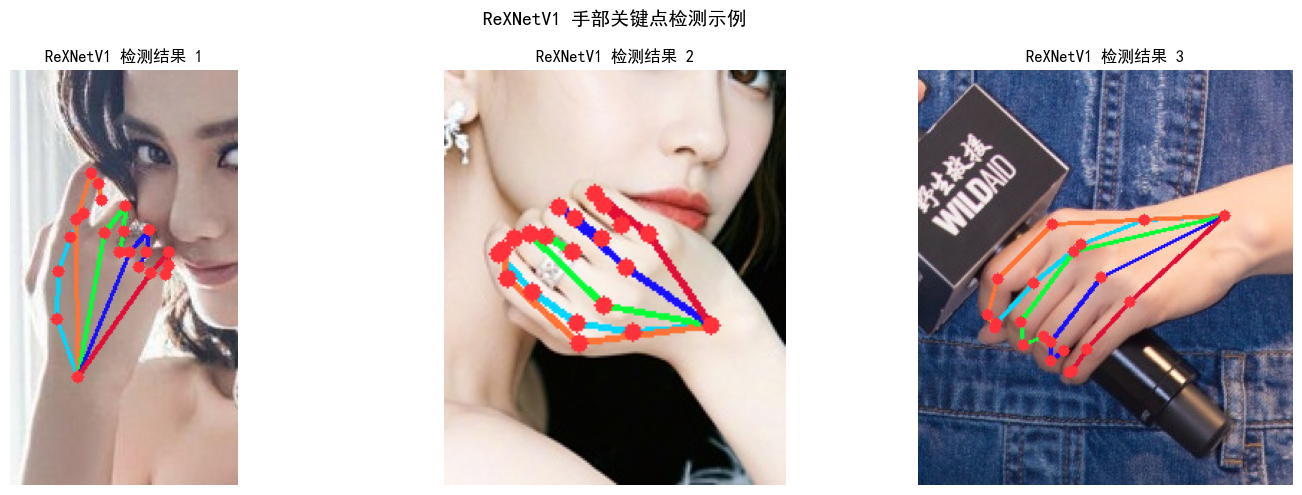

In [172]:
print('\n【5. 检测结果可视化】')
if len(results) > 0:
    best_model_name = results[0]['模型']
    best_cfg = next((c for c in model_configs if c['name'] == best_model_name), None)
    if best_cfg:
        model = best_cfg['build']()
        model.load_state_dict(torch.load(os.path.join(MODEL_DIR, best_cfg['file']), map_location='cpu'))
        model.eval()
        from hand_data_iter.datasets import draw_bd_handpose
        vis_samples = test_samples[:3]
        num_vis = len(vis_samples)
        fig, axes = plt.subplots(1, num_vis, figsize=(5*num_vis, 5))
        if num_vis == 1:
            axes = [axes]
        for idx, (img_path, json_path) in enumerate(vis_samples):
            img = cv2.imread(img_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w = img.shape[:2]
            # 预处理
            img_resized = cv2.resize(img, (256, 256))
            img_tensor = (img_resized.astype(np.float32) - 128.0) / 256.0
            img_tensor = torch.from_numpy(img_tensor.transpose(2, 0, 1)).unsqueeze(0)
            with torch.no_grad():
                out = model(img_tensor).numpy().squeeze()
            pred_dict = {str(i): {"x": out[2*i]*w, "y": out[2*i+1]*h} for i in range(21)}
            vis_img = img_rgb.copy()
            draw_bd_handpose(vis_img, pred_dict, 0, 0)
            for i in range(21):
                x, y = int(pred_dict[str(i)]["x"]), int(pred_dict[str(i)]["y"])
                cv2.circle(vis_img, (x, y), 4, (255, 50, 60), -1)
            axes[idx].imshow(vis_img)
            axes[idx].set_title(f'{best_model_name} 检测结果 {idx+1}')
            axes[idx].axis('off')
        plt.suptitle(f'{best_model_name} 手部关键点检测示例', fontsize=14)
        plt.tight_layout()
        plt.show()

In [209]:
# 查看PyQt5项目结构
import os

project_path = r'd:\学习\深度学习\handpose_x-main'
gui_files = [f for f in os.listdir(project_path) if 'gui' in f.lower() or 'qt' in f.lower()]
print("PyQt5相关文件:")
for f in gui_files:
    print(f"  - {f}")

PyQt5相关文件:
  - add_pyqt5_final.py
  - ai_gesture_gui.py
  - gui_detect.py
